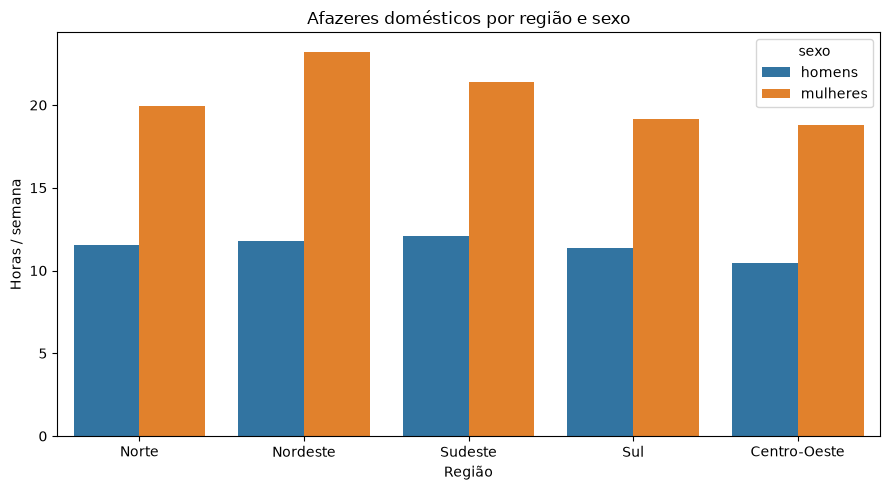

In [ ]:
import matplotlib.pyplot as plt
    import pandas as pd
    import seaborn as sns

path = r"Tabela 1.1.1.xls"

# 1. Lê o arquivo sem usar a primeira linha como cabeçalho
bruto = pd.read_excel(path, engine="xlrd", header=None)

# 2. Seleciona apenas as linhas com os dados (linhas 8 a 40 da planilha)
indicador_1 = bruto.iloc[8:41].copy()

# 3. Define os nomes corretos para as colunas
indicador_1.columns = [
    "uf_regiao",
    "total",
    "total_branca",
    "total_preta_parda",
    "homem_branca",
    "homem_preta_parda",
    "mulher_branca",
    "mulher_preta_parda",
]

indicador_1 = indicador_1.reset_index(drop=True)

# 4. Converte os valores das horas para números
for col in indicador_1.columns[1:]:
    indicador_1[col] = pd.to_numeric(indicador_1[col], errors="coerce")

# 5. Seleção das grandes regiões
regioes = ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]
reg = indicador_1[indicador_1["uf_regiao"].isin(regioes)].copy()

# 6. Média das horas por sexo
reg["homens"] = (reg["homem_branca"] + reg["homem_preta_parda"]) / 2
reg["mulheres"] = (reg["mulher_branca"] + reg["mulher_preta_parda"]) / 2

# 7. Formatação dos dados para o Seaborn
reg_long = reg.melt(
    id_vars="uf_regiao",
    value_vars=["homens", "mulheres"],
    var_name="sexo",
    value_name="horas",
)

# 8. Construção e exibição do gráfico
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=reg_long, x="uf_regiao", y="horas", hue="sexo", ax=ax)

ax.set_title("Afazeres domésticos por região e sexo", fontsize=12)
ax.set_xlabel("Região")
ax.set_ylabel("Horas / semana")

plt.tight_layout()
plt.show()

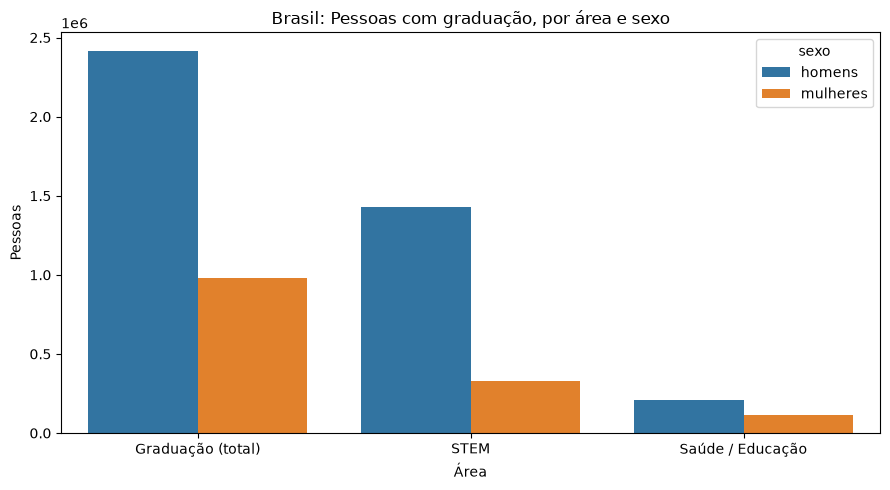

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

path_formacao = r"H:\Python\TERCEIRA_ETAPA\Gráficos\Tabela_3_Areas_gerais_de_formacao_na_graduacao.xlsx"

# 1. Lê o arquivo
bruto_3 = pd.read_excel(path_formacao, engine="openpyxl", header=None)

# 2. Separa os DataFrames
formacao_total = bruto_3.iloc[8:41, [0, 1, 2]].copy()
formacao_total.columns = ["uf_regiao", "total_homens", "total_mulheres"]

formacao_stem = bruto_3.iloc[8:41, [0, 3, 4]].copy()
formacao_stem.columns = ["uf_regiao", "homens", "mulheres"]

formacao_saude = bruto_3.iloc[8:41, [0, 5, 6]].copy()
formacao_saude.columns = ["uf_regiao", "homens", "mulheres"]

# Função auxiliar para extrair o valor da linha do Brasil com segurança
def pegar_valor_brasil(df, coluna):
    # Procura por 'brasil' ignorando maiúsculas/minúsculas e espaços
    filtro = df["uf_regiao"].astype(str).str.strip().str.lower() == "brasil"
    resultado = df.loc[filtro, coluna]
    if len(resultado) > 0:
        return pd.to_numeric(resultado.values[0], errors="coerce")
    else:
        # Se não encontrar 'Brasil', pega a primeira linha da tabela (linha do total)
        return pd.to_numeric(df[coluna].iloc[0], errors="coerce")

# 3. Consolidação segura
brasil = pd.DataFrame(
    {
        "area": ["Graduação (total)", "STEM", "Saúde / Educação"],
        "homens": [
            pegar_valor_brasil(formacao_total, "total_homens"),
            pegar_valor_brasil(formacao_stem, "homens"),
            pegar_valor_brasil(formacao_saude, "homens"),
        ],
        "mulheres": [
            pegar_valor_brasil(formacao_total, "total_mulheres"),
            pegar_valor_brasil(formacao_stem, "mulheres"),
            pegar_valor_brasil(formacao_saude, "mulheres"),
        ],
    }
)

# 4. Formatação e Gráfico
brasil_long = brasil.melt(
    id_vars="area", var_name="sexo", value_name="pessoas"
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=brasil_long, x="area", y="pessoas", hue="sexo", ax=ax)

ax.set_title("Brasil: Pessoas com graduação, por área e sexo", fontsize=12)
ax.set_xlabel("Área")
ax.set_ylabel("Pessoas")

plt.tight_layout()
plt.show()

In [ ]:
import openpyxl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

path = r"H:\Python\TERCEIRA_ETAPA\Atividade_04\CD2022_Populacao_2010_Compatibilizada_20231222.xlsx"

df = pd.read_excel(path, header=2)
df

,Unnamed: 0,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,População Município 2010\n(Sinopse),População 2010 (Alterações de Limites até 2022)1,População Censo 2022
0,NaN,RO,11.0,15.0,Alta Floresta D'Oeste,24392.0,24392.0,21494.0
1,NaN,RO,11.0,23.0,Ariquemes,90353.0,90353.0,96833.0
2,NaN,RO,11.0,31.0,Cabixi,6313.0,6313.0,5351.0
3,NaN,RO,11.0,49.0,Cacoal,78574.0,78574.0,86887.0
4,NaN,RO,11.0,56.0,Cerejeiras,17029.0,17029.0,15890.0
...,...,...,...,...,...,...,...,...
5569,NaN,DF,53.0,108.0,Brasília,2570160.0,2572159.0,2817381.0
5570,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5571,NaN,Nota: Para o cálculo das taxas de crescimento ...,NaN,NaN,NaN,NaN,NaN,NaN
5572,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
tabelaCorreta = df.iloc[0:5570, 1:]
tabelaCorreta

tabelaCorreta["Diferença"] = tabelaCorreta["População Município 2010\n(Sinopse)"] - tabelaCorreta["População Censo 2022"]
tabelaCorreta

tabelaCorreta.to_csv(r"H:\Python\TERCEIRA_ETAPA\Atividade_04\tabela_diferença.csv", sep=";")

In [ ]:
tabelaNova = (
    tabelaCorreta.groupby("UF")[
        [
            "População Município 2010\n(Sinopse)",
            "População Censo 2022",
            "Diferença",
        ]
    ]
    .sum()
    .reset_index()
)

tabelaNova

tabelaNova.to_csv(r"H:\Python\TERCEIRA_ETAPA\Atividade_04\tabela_Nova.csv", sep=";")

In [ ]:
tabelaMunicipio = (
    tabelaCorreta.groupby("NOME DO MUNICÍPIO")[
        [
            "População Município 2010\n(Sinopse)",
            "População Censo 2022",
            "Diferença",
        ]
    ]
    .sum()
    .reset_index()
)

tabelaMunicipio

tabelaMunicipio.to_csv(r"H:\Python\TERCEIRA_ETAPA\Atividade_04\tabela_Municipio.csv", sep=";")

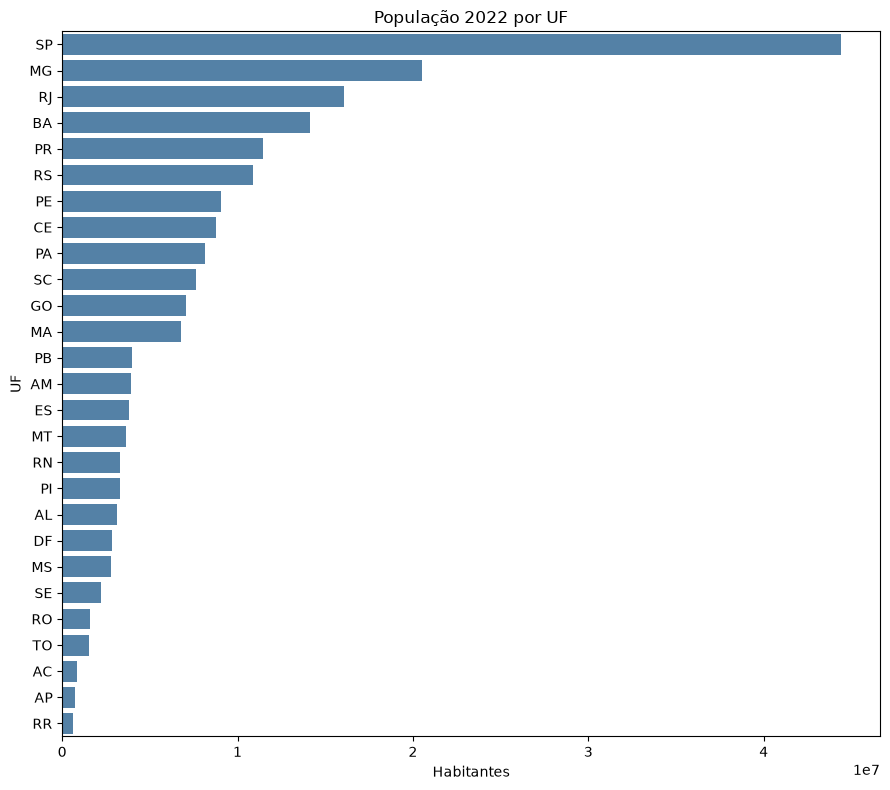

In [ ]:
fig, ax = plt.subplots(figsize=(9, 8))
ordem = tabelaNova.sort_values("População Censo 2022", ascending=False)
sns.barplot(data=ordem, y="UF", x="População Censo 2022", ax=ax, color="steelblue")
ax.set_title("População 2022 por UF")
ax.set_xlabel("Habitantes")
ax.set_ylabel("UF")
plt.tight_layout()
plt.show()